#Import Required Libraries

In [15]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Data preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Model saving
import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

##  Dataset Loading



In [16]:
import os

file_path = "/content/construction_delivery_dataset.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Dataset file not found at this path: {file_path}")

print("Dataset file found successfully")

Dataset file found successfully


# Dataset Structure

In [17]:
df = pd.read_csv(file_path)
display(df.head())
df.info()

,delivery_event_id,order_placed_date,committed_delivery_date,material_category,supplier_tier,planned_lead_calendar_days,distance_supplier_to_site_km,delivery_terms,site_access_restriction_level,project_sector,region_site,order_value_band_gbp,shipment_mode,import_or_customs_hold_liable,made_to_order_or_long_fabrication,upstream_delay_flag_programme,market_shortage_stress_band,po_line_changes_before_release_count,weather_or_temperature_sensitive_goods,busy_season_construction_index,jit_critical_path_item,supplier_rolling_otif_band,haulier_capacity_stress_quarter,packaging_handling_complexity,material_delivery_delayed_gt_3_working_days
0,CSC-DEL-0000000001,17-11-2023,03-01-2024,Structural Steel & Metalwork,Approved – Regional,47,89,FCA – Collect Ex-Works,Standard Laydown,Commercial / Offices,North West,£2k – £15k,Full Load – Direct,No,Yes,Yes,Moderate,0,No,Low,No,85% – 94%,No,Oversize – Permit / Escort,0
1,CSC-DEL-0000000002,21-05-2023,17-07-2023,Structural Steel & Metalwork,Preferred – Framework,57,89,DAP – Delivered at Site,Standard Laydown,Industrial / Logistics,Wales & West,£15k – £75k,Consolidated Hub,No,Yes,No,Low,0,No,Typical,No,Under 85%,No,Fragile / Sequenced Unload,0
2,CSC-DEL-0000000003,15-08-2024,27-08-2024,General Merchanted Goods,Preferred – Framework,12,104,DAP – Delivered at Site,Standard Laydown,Commercial / Offices,Scotland,£2k – £15k,Consolidated Hub,Yes,No,No,High,1,No,Typical,No,95%+,No,Fragile / Sequenced Unload,0
3,CSC-DEL-0000000004,24-12-2024,05-01-2025,MEP – Cable & Containment,Preferred – Framework,12,82,CPT – Carriage Paid To Yard,Standard Laydown,Industrial / Logistics,London & South East,£75k – £250k,Part Load / Groupage,No,No,Yes,Moderate,1,No,Typical,No,85% – 94%,Yes,Standard Pallet / Bulk,0
4,CSC-DEL-0000000005,24-08-2024,25-08-2024,Ready-Mix & Aggregates,Preferred – Framework,1,83,DAP – Delivered at Site,Standard Laydown,Infrastructure / Civils,North West,£2k – £15k,Full Load – Direct,No,No,No,Low,0,Yes,Low,Yes,Under 85%,No,Standard Pallet / Bulk,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68062 entries, 0 to 68061
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype 
---  ------                                       --------------  ----- 
 0   delivery_event_id                            68062 non-null  object
 1   order_placed_date                            68062 non-null  object
 2   committed_delivery_date                      68062 non-null  object
 3   material_category                            68062 non-null  object
 4   supplier_tier                                68062 non-null  object
 5   planned_lead_calendar_days                   68062 non-null  int64 
 6   distance_supplier_to_site_km                 68062 non-null  int64 
 7   delivery_terms                               68062 non-null  object
 8   site_access_restriction_level                68062 non-null  object
 9   project_sector                               68062 non-null  object
 10  region_sit

# Required Column Check

In [18]:
expected_columns = [
    "delivery_event_id",
    "order_placed_date",
    "committed_delivery_date",
    "material_category",
    "supplier_tier",
    "planned_lead_calendar_days",
    "distance_supplier_to_site_km",
    "delivery_terms",
    "site_access_restriction_level",
    "project_sector",
    "region_site",
    "order_value_band_gbp",
    "shipment_mode",
    "import_or_customs_hold_liable",
    "made_to_order_or_long_fabrication",
    "upstream_delay_flag_programme",
    "market_shortage_stress_band",
    "po_line_changes_before_release_count",
    "weather_or_temperature_sensitive_goods",
    "busy_season_construction_index",
    "jit_critical_path_item",
    "supplier_rolling_otif_band",
    "haulier_capacity_stress_quarter",
    "packaging_handling_complexity",
    "material_delivery_delayed_gt_3_working_days"
]

missing_columns = [col for col in expected_columns if col not in df.columns]
extra_columns = [col for col in df.columns if col not in expected_columns]

print("Missing Columns:", missing_columns)
print("Extra Columns:", extra_columns)

if missing_columns:
    raise ValueError("Some required columns are missing from the dataset.")

Missing Columns: []
Extra Columns: []


# Data Quality Summary

In [19]:
data_quality_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isna().sum().values,
    "Missing Percentage": (df.isna().mean() * 100).round(2).values,
    "Unique Values": df.nunique(dropna=True).values
})

display(data_quality_summary)

duplicate_rows = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_rows}")

,Column,Data Type,Missing Values,Missing Percentage,Unique Values
0,delivery_event_id,object,0,0.0,68062
1,order_placed_date,object,0,0.0,1344
2,committed_delivery_date,object,0,0.0,1505
3,material_category,object,0,0.0,10
4,supplier_tier,object,0,0.0,3
5,planned_lead_calendar_days,int64,0,0.0,71
6,distance_supplier_to_site_km,int64,0,0.0,382
7,delivery_terms,object,0,0.0,4
8,site_access_restriction_level,object,0,0.0,4
9,project_sector,object,0,0.0,5


Duplicate Rows: 0


# Target Analysis

,Target Value,Count,Percentage
0,0,50454,74.13
1,1,17608,25.87


<Figure size 600x400 with 0 Axes>

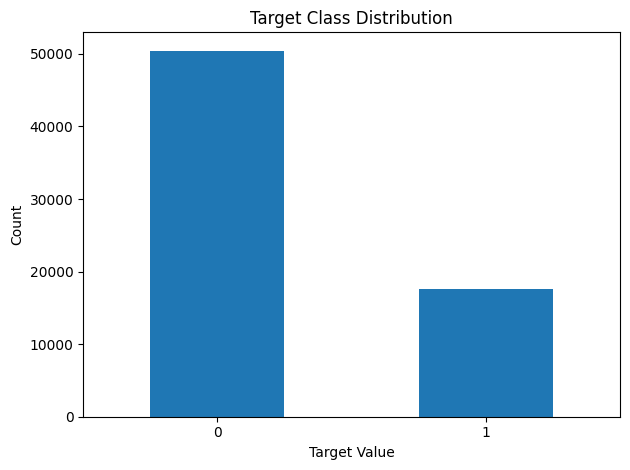

In [20]:
target_col = "material_delivery_delayed_gt_3_working_days"

target_summary = (
    df[target_col]
    .value_counts(dropna=False)
    .rename_axis("Target Value")
    .reset_index(name="Count")
)

target_summary["Percentage"] = (target_summary["Count"] / len(df) * 100).round(2)

display(target_summary)

plt.figure(figsize=(6, 4))
target_summary.sort_values("Target Value").plot(
    x="Target Value",
    y="Count",
    kind="bar",
    legend=False
)
plt.title("Target Class Distribution")
plt.xlabel("Target Value")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Date Validation

In [21]:
date_columns = ["order_placed_date", "committed_delivery_date"]

date_validation = []

for col in date_columns:
    raw_values = df[col].copy()
    parsed_values = pd.to_datetime(raw_values, errors="coerce")

    date_validation.append({
        "Column": col,
        "Missing Values": raw_values.isna().sum(),
        "Invalid Date Values": (raw_values.notna() & parsed_values.isna()).sum()
    })

    df[col] = parsed_values

date_validation_summary = pd.DataFrame(date_validation)
display(date_validation_summary)

df["calculated_lead_calendar_days"] = (
    df["committed_delivery_date"] - df["order_placed_date"]
).dt.days

df["lead_day_difference"] = (
    df["calculated_lead_calendar_days"] - df["planned_lead_calendar_days"]
)

lead_validation_summary = pd.DataFrame({
    "Metric": [
        "Negative Lead Days",
        "Exact Lead Day Matches",
        "Lead Day Mismatches"
    ],
    "Count": [
        (df["calculated_lead_calendar_days"] < 0).sum(),
        (df["lead_day_difference"] == 0).sum(),
        (df["lead_day_difference"] != 0).sum()
    ]
})

display(lead_validation_summary)

display(
    df[
        [
            "order_placed_date",
            "committed_delivery_date",
            "planned_lead_calendar_days",
            "calculated_lead_calendar_days",
            "lead_day_difference"
        ]
    ].head()
)

,Column,Missing Values,Invalid Date Values
0,order_placed_date,0,0
1,committed_delivery_date,0,41956


,Metric,Count
0,Negative Lead Days,11699
1,Exact Lead Day Matches,2183
2,Lead Day Mismatches,65879


,order_placed_date,committed_delivery_date,planned_lead_calendar_days,calculated_lead_calendar_days,lead_day_difference
0,2023-11-17,2024-03-01,47,105.0,58.0
1,2023-05-21,NaT,57,NaN,NaN
2,2024-08-15,NaT,12,NaN,NaN
3,2024-12-24,2025-05-01,12,128.0,116.0
4,2024-08-24,NaT,1,NaN,NaN


# Exploratory Data Analysis

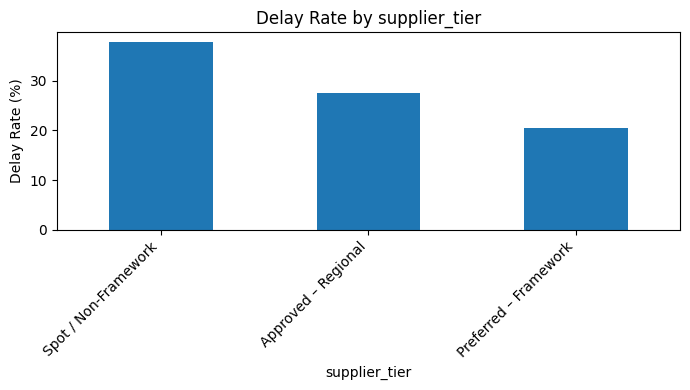

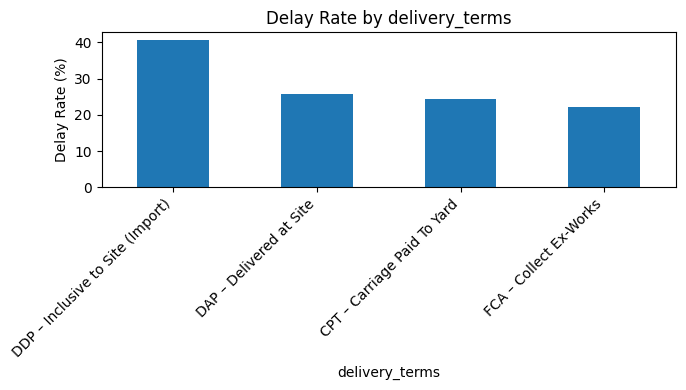

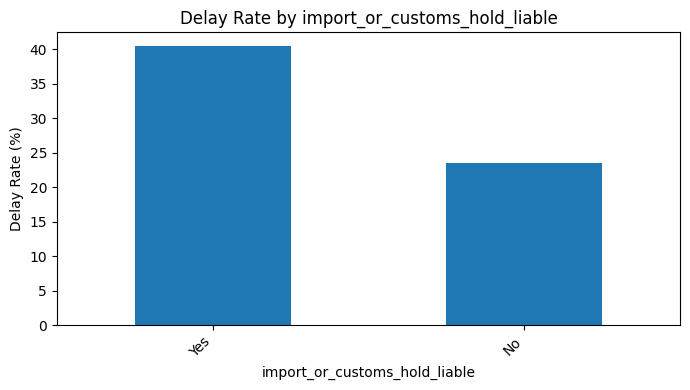

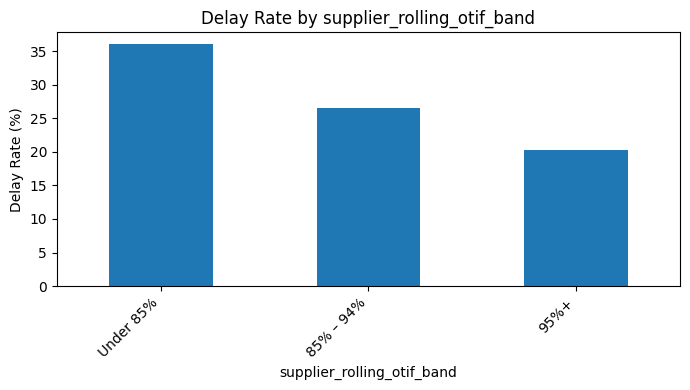

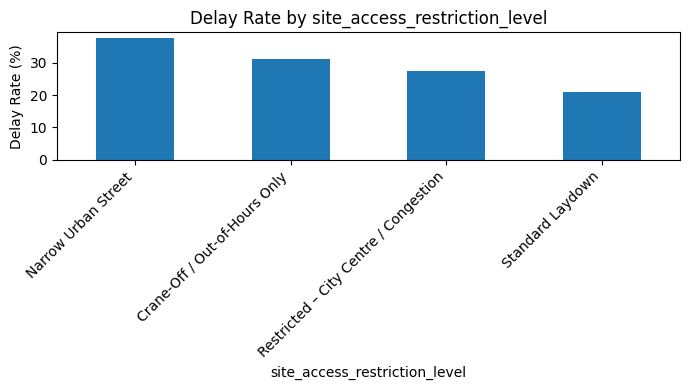

In [22]:
delay_rate_columns = [
    "supplier_tier",
    "delivery_terms",
    "import_or_customs_hold_liable",
    "supplier_rolling_otif_band",
    "site_access_restriction_level"
]

for col in delay_rate_columns:
    delay_rate = (
        df.groupby(col)[target_col]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(7, 4))
    delay_rate.plot(kind="bar")
    plt.title(f"Delay Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Delay Rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Numerical Feature Distributions

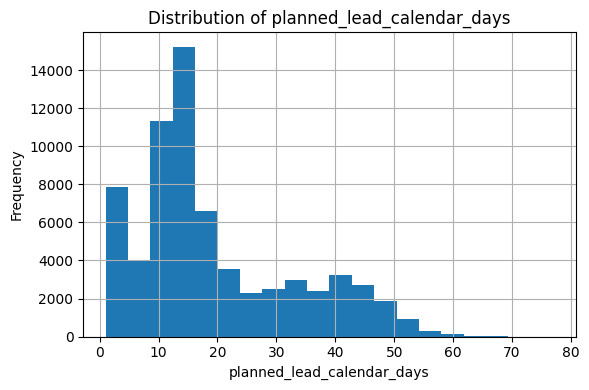

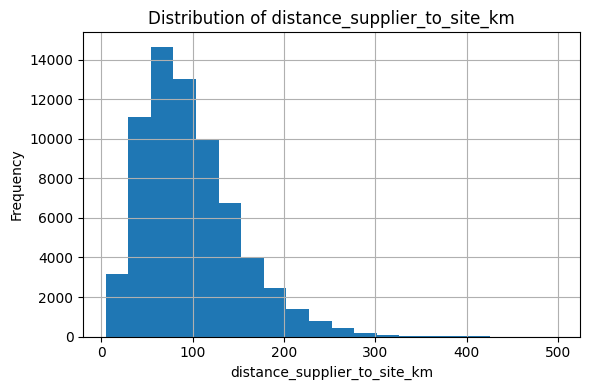

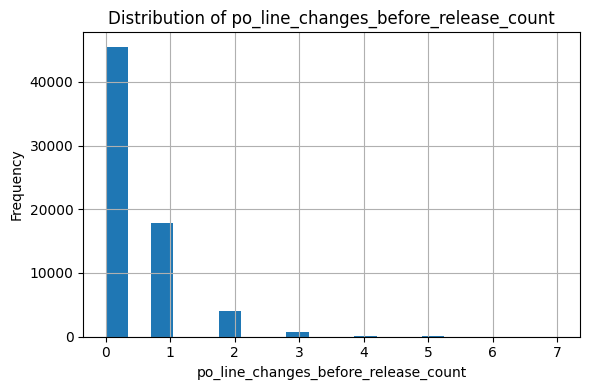

In [23]:
numeric_eda_columns = [
    "planned_lead_calendar_days",
    "distance_supplier_to_site_km",
    "po_line_changes_before_release_count"
]

for col in numeric_eda_columns:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Feature Engineering

In [24]:
valid_target_values = set(df[target_col].dropna().unique())

if not valid_target_values.issubset({0, 1}):
    raise ValueError("Target column must contain only 0 and 1 values.")

model_df = df.copy()

model_df["order_month"] = model_df["order_placed_date"].dt.month
model_df["order_dayofweek"] = model_df["order_placed_date"].dt.dayofweek
model_df["committed_month"] = model_df["committed_delivery_date"].dt.month
model_df["committed_dayofweek"] = model_df["committed_delivery_date"].dt.dayofweek
model_df["committed_is_weekend"] = model_df["committed_dayofweek"].isin([5, 6]).astype(int)

columns_to_drop = [
    "delivery_event_id",
    "order_placed_date",
    "committed_delivery_date",
    "calculated_lead_calendar_days",
    "lead_day_difference"
]

model_df = model_df.drop(columns=columns_to_drop, errors="ignore")

X = model_df.drop(columns=[target_col])
y = model_df[target_col].astype(int)

print(f"Feature rows: {X.shape[0]}")
print(f"Feature columns: {X.shape[1]}")
print(f"Target rows: {y.shape[0]}")

Feature rows: 68062
Feature columns: 26
Target rows: 68062


# Train-Test Split

In [25]:
TEST_SIZE = 0.20
RANDOM_STATE = 42

if "X" not in globals() or "y" not in globals():
    raise NameError("Run Cell 20 first to create X and y.")

if y.isna().sum() > 0:
    raise ValueError("Target column contains missing values. Please clean the target before splitting.")

class_counts = y.value_counts().sort_index()
display(pd.DataFrame({
    "Target Value": class_counts.index,
    "Count": class_counts.values,
    "Percentage": (class_counts.values / len(y) * 100).round(2)
}))

if class_counts.min() < 2:
    raise ValueError("Each target class must have at least 2 records for stratified train-test split.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

train_distribution = y_train.value_counts(normalize=True).mul(100).round(2).reindex([0, 1])
test_distribution = y_test.value_counts(normalize=True).mul(100).round(2).reindex([0, 1])

split_summary = pd.DataFrame({
    "Train Percentage": train_distribution,
    "Test Percentage": test_distribution
})

display(split_summary)

print(f"Training records: {X_train.shape[0]}")
print(f"Testing records: {X_test.shape[0]}")

,Target Value,Count,Percentage
0,0,50454,74.13
1,1,17608,25.87


,Train Percentage,Test Percentage
material_delivery_delayed_gt_3_working_days,,
0,74.13,74.13
1,25.87,25.87


Training records: 54449
Testing records: 13613


# Preprocessing Pipeline

In [26]:
from sklearn.impute import SimpleImputer

numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['planned_lead_calendar_days', 'distance_supplier_to_site_km', 'po_line_changes_before_release_count', 'committed_month', 'committed_dayofweek', 'committed_is_weekend']
Categorical Columns: ['material_category', 'supplier_tier', 'delivery_terms', 'site_access_restriction_level', 'project_sector', 'region_site', 'order_value_band_gbp', 'shipment_mode', 'import_or_customs_hold_liable', 'made_to_order_or_long_fabrication', 'upstream_delay_flag_programme', 'market_shortage_stress_band', 'weather_or_temperature_sensitive_goods', 'busy_season_construction_index', 'jit_critical_path_item', 'supplier_rolling_otif_band', 'haulier_capacity_stress_quarter', 'packaging_handling_complexity']


# Multiple Model Training

In [27]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    print(f"Trained: {model_name}")

Trained: Logistic Regression
Trained: Random Forest
Trained: Gradient Boosting
Trained: Hist Gradient Boosting


# Model Evaluation

In [28]:
evaluation_results = []

for model_name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba)
    })

model_comparison = pd.DataFrame(evaluation_results)

score_columns = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
model_comparison[score_columns] = model_comparison[score_columns].round(4)

model_comparison = model_comparison.sort_values(
    by=["Recall", "F1-score", "PR-AUC", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.6646,0.4056,0.6369,0.4956,0.7132,0.4737
1,Hist Gradient Boosting,0.7552,0.6042,0.1556,0.2475,0.7046,0.4606
2,Gradient Boosting,0.7540,0.6270,0.1212,0.2032,0.7078,0.4666
3,Random Forest,0.7502,0.6282,0.0849,0.1496,0.6881,0.4383


# Best Model Selection

In [29]:
best_model_name = "Logistic Regression"
best_model = trained_models[best_model_name]

selected_model_result = model_comparison[
    model_comparison["Model"] == best_model_name
]

display(selected_model_result)

print(f"Selected Model: {best_model_name}")
print("Reason: This model gives the strongest delayed-class recall and F1-score, which is more useful for identifying risky deliveries.")

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.6646,0.4056,0.6369,0.4956,0.7132,0.4737


Selected Model: Logistic Regression
Reason: This model gives the strongest delayed-class recall and F1-score, which is more useful for identifying risky deliveries.


# Model Comparison Chart

<Figure size 1000x500 with 0 Axes>

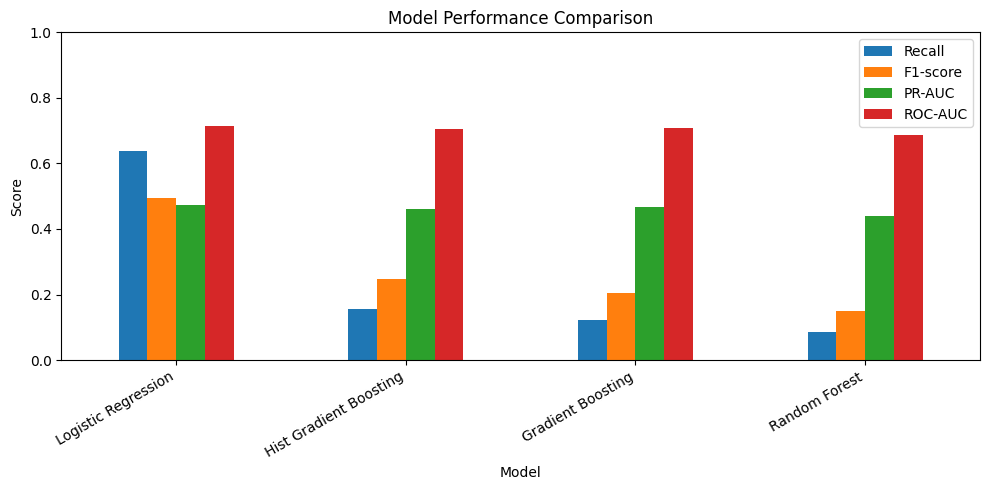

In [30]:
chart_data = model_comparison.set_index("Model")[["Recall", "F1-score", "PR-AUC", "ROC-AUC"]]

plt.figure(figsize=(10, 5))
chart_data.plot(kind="bar", figsize=(10, 5))
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Best Model Selection

In [31]:
selection_table = model_comparison.copy()

selection_table["Selection Score"] = (
    selection_table["Recall"] * 0.35 +
    selection_table["F1-score"] * 0.30 +
    selection_table["PR-AUC"] * 0.20 +
    selection_table["ROC-AUC"] * 0.15
).round(4)

selection_table = selection_table.sort_values(
    by=["Selection Score", "Recall", "F1-score", "PR-AUC"],
    ascending=False
).reset_index(drop=True)

best_model_name = selection_table.loc[0, "Model"]
best_model = trained_models[best_model_name]

display(selection_table)

print(f"Selected Model: {best_model_name}")
print("Selection focus: recall, F1-score, PR-AUC, ROC-AUC, and planning usefulness.")

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Selection Score
0,Logistic Regression,0.6646,0.4056,0.6369,0.4956,0.7132,0.4737,0.5733
1,Hist Gradient Boosting,0.7552,0.6042,0.1556,0.2475,0.7046,0.4606,0.3265
2,Gradient Boosting,0.7540,0.6270,0.1212,0.2032,0.7078,0.4666,0.3029
3,Random Forest,0.7502,0.6282,0.0849,0.1496,0.6881,0.4383,0.2655


Selected Model: Logistic Regression
Selection focus: recall, F1-score, PR-AUC, ROC-AUC, and planning usefulness.


# Threshold Tuning

In [32]:
best_model_proba = best_model.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):
    threshold = round(threshold, 2)
    threshold_pred = (best_model_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, threshold_pred, zero_division=0),
        "Recall": recall_score(y_test, threshold_pred, zero_division=0),
        "F1-score": f1_score(y_test, threshold_pred, zero_division=0),
        "Flagged Percentage": threshold_pred.mean() * 100
    })

threshold_comparison = pd.DataFrame(threshold_results)

threshold_comparison[["Precision", "Recall", "F1-score"]] = (
    threshold_comparison[["Precision", "Recall", "F1-score"]].round(4)
)

threshold_comparison["Flagged Percentage"] = threshold_comparison["Flagged Percentage"].round(2)

display(threshold_comparison)

,Threshold,Precision,Recall,F1-score,Flagged Percentage
0,0.30,0.3025,0.9276,0.4562,79.34
1,0.35,0.3227,0.8745,0.4715,70.10
2,0.40,0.3463,0.8015,0.4836,59.88
3,0.45,0.3750,0.7306,0.4956,50.41
4,0.50,0.4056,0.6369,0.4956,40.62
5,0.55,0.4363,0.5463,0.4851,32.40
6,0.60,0.4693,0.4469,0.4578,24.64
7,0.65,0.5095,0.3509,0.4156,17.82
8,0.70,0.5657,0.2615,0.3577,11.96


# Final Threshold Selection

In [33]:
final_threshold = 0.45

selected_threshold_result = threshold_comparison[
    threshold_comparison["Threshold"] == final_threshold
]

display(selected_threshold_result)

print(f"Final Threshold Selected: {final_threshold}")
print("Reason: This threshold improves delayed-class recall while keeping F1-score balanced for planning decisions.")

,Threshold,Precision,Recall,F1-score,Flagged Percentage
3,0.45,0.375,0.7306,0.4956,50.41


Final Threshold Selected: 0.45
Reason: This threshold improves delayed-class recall while keeping F1-score balanced for planning decisions.


# Final Model Evaluation

In [34]:
final_proba = best_model.predict_proba(X_test)[:, 1]
final_pred = (final_proba >= final_threshold).astype(int)

final_metrics = pd.DataFrame([{
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred, zero_division=0),
    "Recall": recall_score(y_test, final_pred, zero_division=0),
    "F1-score": f1_score(y_test, final_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, final_proba),
    "PR-AUC": average_precision_score(y_test, final_proba)
}])

final_metrics = final_metrics.round(4)
display(final_metrics)

print(classification_report(
    y_test,
    final_pred,
    target_names=["Not Delayed", "Delayed"],
    zero_division=0
))

cm = confusion_matrix(y_test, final_pred, labels=[0, 1])

confusion_matrix_summary = pd.DataFrame(
    cm,
    index=["Actual Not Delayed", "Actual Delayed"],
    columns=["Predicted Not Delayed", "Predicted Delayed"]
)

display(confusion_matrix_summary)

tn, fp, fn, tp = cm.ravel()

print(f"False Positives: {fp} deliveries flagged as risky but not actually delayed.")
print(f"False Negatives: {fn} delayed deliveries missed by the model.")

,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,0.6152,0.375,0.7306,0.4956,0.7132,0.4737


              precision    recall  f1-score   support

 Not Delayed       0.86      0.57      0.69     10091
     Delayed       0.37      0.73      0.50      3522

    accuracy                           0.62     13613
   macro avg       0.62      0.65      0.59     13613
weighted avg       0.73      0.62      0.64     13613



,Predicted Not Delayed,Predicted Delayed
Actual Not Delayed,5802,4289
Actual Delayed,949,2573


False Positives: 4289 deliveries flagged as risky but not actually delayed.
False Negatives: 949 delayed deliveries missed by the model.


# Feature Importance

,Feature,Coefficient,Absolute Importance
0,supplier_tier_Spot / Non-Framework,0.554364,0.554364
1,supplier_rolling_otif_band_Under 85%,0.531325,0.531325
2,import_or_customs_hold_liable_Yes,0.459767,0.459767
3,site_access_restriction_level_Narrow Urban Street,0.439634,0.439634
4,market_shortage_stress_band_High,0.419355,0.419355
5,site_access_restriction_level_Standard Laydown,-0.405100,0.405100
6,supplier_tier_Preferred – Framework,-0.400036,0.400036
7,supplier_rolling_otif_band_95%+,-0.375218,0.375218
8,busy_season_construction_index_Peak,0.367234,0.367234
9,haulier_capacity_stress_quarter_Yes,0.291118,0.291118


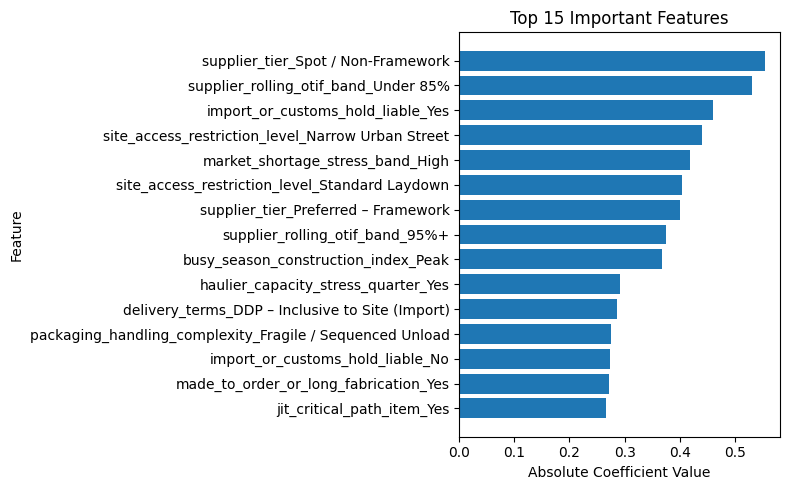

In [35]:
final_model = best_model.named_steps["model"]
final_preprocessor = best_model.named_steps["preprocessor"]

if hasattr(final_model, "coef_"):
    feature_names = final_preprocessor.get_feature_names_out()
    feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

    coefficients = final_model.coef_[0]

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Absolute Importance": np.abs(coefficients)
    })

    feature_importance = feature_importance.sort_values(
        by="Absolute Importance",
        ascending=False
    ).reset_index(drop=True)

    top_features = feature_importance.head(15)

    display(top_features)

    plt.figure(figsize=(8, 5))
    plt.barh(top_features["Feature"][::-1], top_features["Absolute Importance"][::-1])
    plt.title("Top 15 Important Features")
    plt.xlabel("Absolute Coefficient Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance is not directly supported by the selected model.")

# Business Recommendation Logic

In [36]:
def get_delivery_recommendation(probability):
    if probability < 0.30:
        risk_level = "Low Risk"
        recommendation = "Continue routine monitoring. No immediate planning change is required."

    elif probability < final_threshold:
        risk_level = "Medium Risk"
        recommendation = (
            "Monitor the supplier and delivery schedule. Check supplier communication, "
            "site readiness, and early warning signals."
        )

    elif probability < 0.65:
        risk_level = "High Risk"
        recommendation = (
            "Review supplier reliability, customs risk, carrier capacity, and site access. "
            "Prepare resequencing options for affected work packages."
        )

    else:
        risk_level = "Very High Risk"
        recommendation = (
            "Escalate as a critical-path delivery risk. Consider switching carrier, "
            "expediting the order, confirming customs clearance, and resequencing work."
        )

    return risk_level, recommendation

# Test Recommendations on Sample Records

In [37]:
sample_records = X_test.sample(5, random_state=RANDOM_STATE)

sample_probabilities = best_model.predict_proba(sample_records)[:, 1]
sample_predictions = (sample_probabilities >= final_threshold).astype(int)

recommendation_results = []

for index, probability, prediction in zip(sample_records.index, sample_probabilities, sample_predictions):
    risk_level, recommendation = get_delivery_recommendation(probability)

    recommendation_results.append({
        "Record Index": index,
        "Delay Probability": round(probability, 4),
        "Predicted Class": prediction,
        "Risk Level": risk_level,
        "Recommendation": recommendation
    })

recommendation_results = pd.DataFrame(recommendation_results)

display(recommendation_results)

,Record Index,Delay Probability,Predicted Class,Risk Level,Recommendation
0,20649,0.3550,0,Medium Risk,Monitor the supplier and delivery schedule. Ch...
1,5967,0.7418,1,Very High Risk,Escalate as a critical-path delivery risk. Con...
2,34617,0.3123,0,Medium Risk,Monitor the supplier and delivery schedule. Ch...
3,55388,0.3794,0,Medium Risk,Monitor the supplier and delivery schedule. Ch...
4,8564,0.4807,1,High Risk,"Review supplier reliability, customs risk, car..."


# Save Final Model

In [38]:
model_package = {
    "model": best_model,
    "threshold": final_threshold,
    "target_column": target_col,
    "feature_columns": X.columns.tolist()
}

model_file_name = "construction_delivery_slippage_model.pkl"

joblib.dump(model_package, model_file_name)

print(f"Model saved successfully: {model_file_name}")

Model saved successfully: construction_delivery_slippage_model.pkl


# Test Saved Model

In [39]:
loaded_package = joblib.load("construction_delivery_slippage_model.pkl")

loaded_model = loaded_package["model"]
loaded_threshold = loaded_package["threshold"]

saved_model_samples = X_test.sample(5, random_state=RANDOM_STATE)

saved_model_probabilities = loaded_model.predict_proba(saved_model_samples)[:, 1]
saved_model_predictions = (saved_model_probabilities >= loaded_threshold).astype(int)

saved_model_results = []

for index, probability, prediction in zip(
    saved_model_samples.index,
    saved_model_probabilities,
    saved_model_predictions
):
    risk_level, recommendation = get_delivery_recommendation(probability)

    saved_model_results.append({
        "Record Index": index,
        "Delay Probability": round(probability, 4),
        "Predicted Class": prediction,
        "Actual Class": y_test.loc[index],
        "Risk Level": risk_level,
        "Recommendation": recommendation
    })

saved_model_results = pd.DataFrame(saved_model_results)

display(saved_model_results)

print("Saved model loaded and tested successfully.")
print(f"Loaded Threshold: {loaded_threshold}")

,Record Index,Delay Probability,Predicted Class,Actual Class,Risk Level,Recommendation
0,20649,0.3550,0,0,Medium Risk,Monitor the supplier and delivery schedule. Ch...
1,5967,0.7418,1,0,Very High Risk,Escalate as a critical-path delivery risk. Con...
2,34617,0.3123,0,0,Medium Risk,Monitor the supplier and delivery schedule. Ch...
3,55388,0.3794,0,0,Medium Risk,Monitor the supplier and delivery schedule. Ch...
4,8564,0.4807,1,0,High Risk,"Review supplier reliability, customs risk, car..."


Saved model loaded and tested successfully.
Loaded Threshold: 0.45


# Final Project Summary

In [40]:
final_summary = pd.DataFrame({
    "Item": [
        "Project",
        "Selected Model",
        "Final Threshold",
        "Accuracy",
        "Delayed Class Precision",
        "Delayed Class Recall",
        "Delayed Class F1-score",
        "ROC-AUC",
        "PR-AUC",
        "Saved Model File"
    ],
    "Result": [
        "Critical-Path Material Delivery Slippage Prediction",
        best_model_name,
        final_threshold,
        final_metrics.loc[0, "Accuracy"],
        final_metrics.loc[0, "Precision"],
        final_metrics.loc[0, "Recall"],
        final_metrics.loc[0, "F1-score"],
        final_metrics.loc[0, "ROC-AUC"],
        final_metrics.loc[0, "PR-AUC"],
        model_file_name
    ]
})

display(final_summary)

if os.path.exists(model_file_name):
    print("Notebook completed successfully.")
    print("Final model file is available in the Colab Files section.")
else:
    print("Model file not found. Please rerun the model saving cell.")

,Item,Result
0,Project,Critical-Path Material Delivery Slippage Predi...
1,Selected Model,Logistic Regression
2,Final Threshold,0.45
3,Accuracy,0.6152
4,Delayed Class Precision,0.375
5,Delayed Class Recall,0.7306
6,Delayed Class F1-score,0.4956
7,ROC-AUC,0.7132
8,PR-AUC,0.4737
9,Saved Model File,construction_delivery_slippage_model.pkl


Notebook completed successfully.
Final model file is available in the Colab Files section.


In [41]:
import os
from pathlib import Path

for file in Path("/content").glob("*"):
    if file.suffix in [".pkl", ".joblib", ".json"]:
        print(file)

/content/construction_delivery_slippage_model.pkl


In [42]:
from pathlib import Path

files_found = []

for file in Path("/content").rglob("*"):
    if file.suffix.lower() in [".pkl", ".joblib", ".json"]:
        files_found.append(str(file))

print("Total files found:", len(files_found))

for file in files_found:
    print(file)

Total files found: 5
/content/construction_delivery_slippage_model.pkl
/content/.config/.last_update_check.json
/content/model_artifacts/.last_update_check.json
/content/model_artifacts/anscombe.json
/content/sample_data/anscombe.json


In [44]:
import pandas as pd
from sklearn.base import BaseEstimator

print("MODEL VARIABLES FOUND:")
for name, value in globals().items():
    if isinstance(value, BaseEstimator):
        print(name, "->", type(value).__name__)

print("\nDATAFRAME VARIABLES FOUND:")
for name, value in globals().items():
    if isinstance(value, pd.DataFrame):
        print(name, "->", value.shape)

print("\nOTHER POSSIBLE IMPORTANT VARIABLES:")
for name in globals():
    if any(word in name.lower() for word in ["threshold", "feature", "column", "preprocess", "scaler", "encoder"]):
        try:
            print(name, "->", type(globals()[name]).__name__)
        except:
            pass

MODEL VARIABLES FOUND:
numeric_pipeline -> Pipeline
categorical_pipeline -> Pipeline
preprocessor -> ColumnTransformer
model -> HistGradientBoostingClassifier
pipeline -> Pipeline
best_model -> Pipeline
final_model -> LogisticRegression
final_preprocessor -> ColumnTransformer
loaded_model -> Pipeline

DATAFRAME VARIABLES FOUND:
df -> (68062, 27)
data_quality_summary -> (25, 5)
target_summary -> (2, 3)
date_validation_summary -> (2, 3)
lead_validation_summary -> (3, 2)
model_df -> (68062, 27)
X -> (68062, 26)
X_train -> (54449, 26)
X_test -> (13613, 26)
split_summary -> (2, 2)
model_comparison -> (4, 7)
selected_model_result -> (1, 7)
chart_data -> (4, 4)
selection_table -> (4, 8)
threshold_comparison -> (9, 5)
selected_threshold_result -> (1, 5)
final_metrics -> (1, 6)
confusion_matrix_summary -> (2, 2)
feature_importance -> (72, 3)
top_features -> (15, 3)
sample_records -> (5, 26)
recommendation_results -> (5, 5)
saved_model_samples -> (5, 26)
saved_model_results -> (5, 6)
final_summa

In [45]:
from sklearn.pipeline import Pipeline

print("CHECKING FINAL MODEL OBJECTS\n")

candidate_names = ["pipeline", "best_model", "loaded_model"]

for name in candidate_names:
    if name in globals():
        obj = globals()[name]
        print(f"{name}: {type(obj).__name__}")

        try:
            sample_input = X_test.head(5)
            preds = obj.predict(sample_input)
            print(f"  Predict works: YES")
            print(f"  Sample predictions: {preds}")

            if hasattr(obj, "predict_proba"):
                probs = obj.predict_proba(sample_input)[:, 1]
                print(f"  Predict_proba works: YES")
                print(f"  Sample probabilities: {probs}")
            else:
                print("  Predict_proba works: NO")

        except Exception as e:
            print(f"  Predict works: NO")
            print(f"  Error: {e}")

        print()

print("CHECKING SEPARATE FINAL MODEL + PREPROCESSOR\n")

try:
    temp_pipeline = Pipeline([
        ("preprocessor", final_preprocessor),
        ("model", final_model)
    ])

    sample_input = X_test.head(5)
    preds = temp_pipeline.predict(sample_input)
    probs = temp_pipeline.predict_proba(sample_input)[:, 1]

    print("final_preprocessor + final_model pipeline works: YES")
    print("Sample predictions:", preds)
    print("Sample probabilities:", probs)

except Exception as e:
    print("final_preprocessor + final_model pipeline works: NO")
    print("Error:", e)

print("\nFINAL THRESHOLD:")
print(final_threshold)

print("\nFEATURE COLUMN COUNT:")
print(len(list(X_train.columns)))

print("\nFEATURE COLUMNS:")
print(list(X_train.columns))

CHECKING FINAL MODEL OBJECTS

pipeline: Pipeline
  Predict works: YES
  Sample predictions: [0 0 0 0 1]
  Predict_proba works: YES
  Sample probabilities: [0.26361184 0.36294429 0.31882761 0.17955913 0.54277615]

best_model: Pipeline
  Predict works: YES
  Sample predictions: [1 1 0 0 1]
  Predict_proba works: YES
  Sample probabilities: [0.61777555 0.65930157 0.46037905 0.48307066 0.75836433]

loaded_model: Pipeline
  Predict works: YES
  Sample predictions: [1 1 0 0 1]
  Predict_proba works: YES
  Sample probabilities: [0.61777555 0.65930157 0.46037905 0.48307066 0.75836433]

CHECKING SEPARATE FINAL MODEL + PREPROCESSOR

final_preprocessor + final_model pipeline works: YES
Sample predictions: [1 1 0 0 1]
Sample probabilities: [0.61777555 0.65930157 0.46037905 0.48307066 0.75836433]

FINAL THRESHOLD:
0.45

FEATURE COLUMN COUNT:
26

FEATURE COLUMNS:
['material_category', 'supplier_tier', 'planned_lead_calendar_days', 'distance_supplier_to_site_km', 'delivery_terms', 'site_access_restri

In [46]:
import joblib
import json
import shutil
from pathlib import Path
from google.colab import files

artifact_folder = Path("/content/final_model_artifacts")
artifact_folder.mkdir(exist_ok=True)

joblib.dump(best_model, artifact_folder / "final_model_pipeline.joblib")

with open(artifact_folder / "feature_columns.json", "w") as f:
    json.dump(list(X_train.columns), f, indent=4)

metadata = {
    "model_name": "Logistic Regression",
    "target_column": "material_delivery_delayed_gt_3_working_days",
    "threshold": float(final_threshold),
    "model_file": "final_model_pipeline.joblib",
    "feature_count": len(list(X_train.columns))
}

with open(artifact_folder / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

zip_path = "/content/final_model_artifacts.zip"
shutil.make_archive("/content/final_model_artifacts", "zip", artifact_folder)

print("Files saved successfully:")
for file in artifact_folder.iterdir():
    print(file.name)

print("\nZIP created at:")
print(zip_path)

Files saved successfully:
metadata.json
feature_columns.json
final_model_pipeline.joblib

ZIP created at:
/content/final_model_artifacts.zip


In [47]:
import zipfile

zip_path = "/content/final_model_artifacts.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print("Files inside ZIP:")
    for file in zip_ref.namelist():
        print(file)

Files inside ZIP:
metadata.json
feature_columns.json
final_model_pipeline.joblib


In [48]:
from google.colab import files

files.download("/content/final_model_artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>